### Heart Attack Prediction Model using Heart Attack Analysis & Prediction Dataset  

In this section we will see how to evaluate the accuracy of the model using *accuracy_score* which is a function provided by the *sklearn.metrics* module in the **scikit-learn** library.  
It is used to calculate the accuracy of a machine learning model by comparing the true labels (y_true) with the predicted labels (y_pred).  

Equation for Accuracy,

Accuracy = Number of correct predictions / Total number of Predictions


In [7]:
# import the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
# import the dataset

df = pd.read_csv('data/heart.csv')

print(df.head())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [9]:
# define features and target
X = df.drop(columns=['output'])
y = df["output"]

# Standardize the data as a part of preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make Predictions
y_pred = dt_model.predict(X_test)

In [11]:
# evaluating accuracy of model
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Confusion Matrix to show the breakdown of correct and incorrect predictions for each class.
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Decision Tree Accuracy: 0.7362637362637363
Confusion Matrix:
 [[32  9]
 [15 35]]


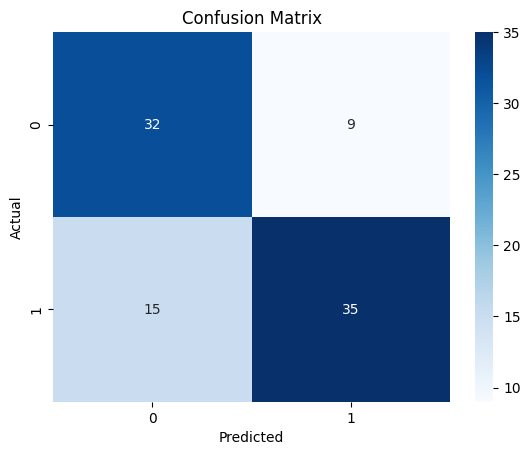

In [15]:
# visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73        41
           1       0.80      0.70      0.74        50

    accuracy                           0.74        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.74      0.74      0.74        91



### Note

Precision: Fraction of correctly predicted samples for a class out of all predicted samples for that class.
Recall: Fraction of correctly predicted samples for a class out of all actual samples of that class.
F1-Score: Harmonic mean of precision and recall.